# Phase 03 — KPIs and Findings
## Rappi Delivery Operations Dataset — Module 1 Business Questions

**Purpose:** Convert the clean dataset into operational KPIs and answer the 5 Module 1 business questions.

| Question | Description |
|---|---|
| **P1** | Which hours and zones reach critical saturation? |
| **P2** | Which external variable correlates with ratio deterioration? |
| **P3** | Which zones are most vulnerable to that variable? |
| **P4** | Is earnings calibration efficient across the month? |
| **P5** | What is the earnings-saturation relationship? |

**Inputs:** `outputs/cleaned/raw_data_clean.parquet`  
**Outputs:** KPI tables and figures in `outputs/tables/` and `outputs/figures/`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker
# import seaborn as sns
from scipy.stats import spearmanr

from src.config import TABLES_DIR, FIGURES_DIR, RATIO_SATURATION, RATIO_HEALTHY_LOW, RATIO_HEALTHY_HIGH
from src.io_utils import load_cleaned, save_csv
from src.feature_engineering import add_all_kpis, add_all_labels
from src.plotting import plot_heatmap, plot_ranked_bar, plot_bubble_grid, save_fig

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 130)

raw = load_cleaned("raw_data_clean")
raw = add_all_kpis(raw)
raw = add_all_labels(raw)
print(f"Loaded {len(raw):,} rows. KPIs added: RATIO, EARNINGS_PER_ORDER, EARNINGS_PER_RIDER, SUPPLY_DEMAND_GAP")

Loaded 10,080 rows. KPIs added: RATIO, EARNINGS_PER_ORDER, EARNINGS_PER_RIDER, SUPPLY_DEMAND_GAP


---
## P1 — Saturation Hours and Zones

**Question:** In which hours and zones does the operation reach critical saturation levels?  
Saturation is defined as `RATIO = ORDERS / CONNECTED_RT > 1.8`

Figure saved → outputs\figures\p1_heatmap_ratio_zone_hour.png


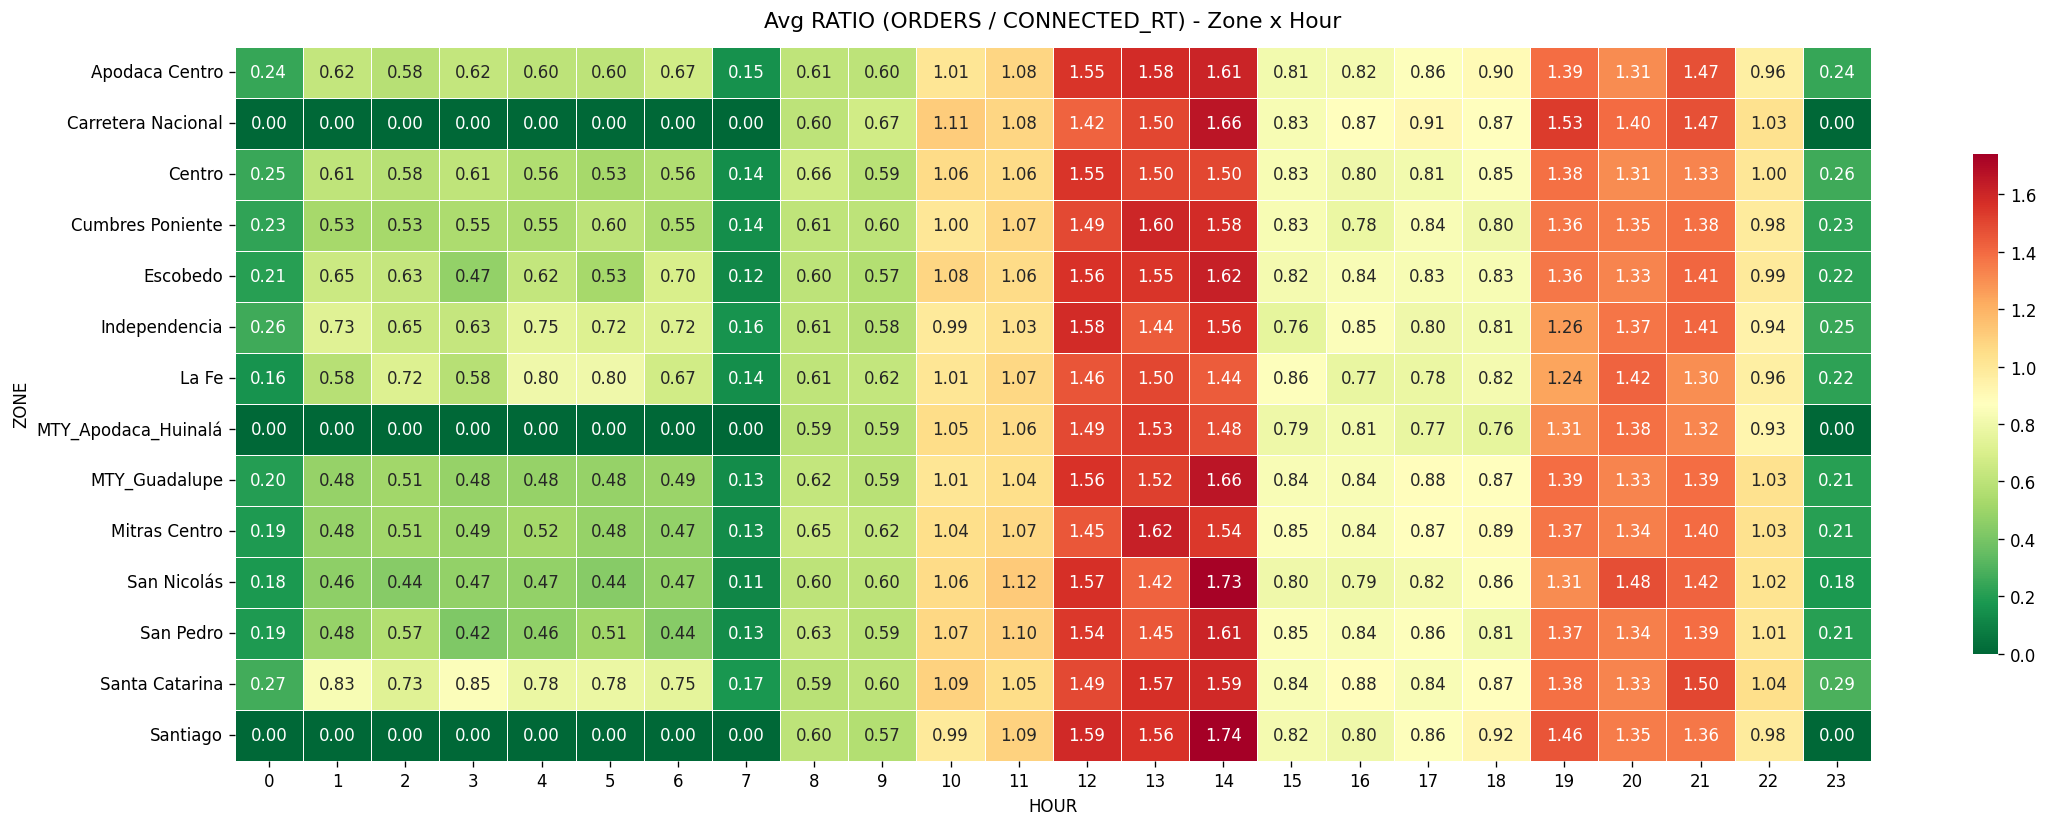

In [2]:
# Zone x Hour heatmap of average RATIO
raw_valid = raw.loc[raw["CONNECTED_RT"] > 0].copy()
raw_valid["IS_SATURATED"] = raw_valid["RATIO"] > RATIO_SATURATION

pivot_ratio = (
    raw_valid.groupby(["ZONE", "HOUR"])["RATIO"]
    .mean()
    .unstack("HOUR")
)
fig = plot_heatmap(
    pivot_ratio.round(2),
    title="Avg RATIO (ORDERS / CONNECTED_RT) - Zone x Hour",
    cmap="RdYlGn_r",
    fmt=".2f",
)
save_fig(fig, "p1_heatmap_ratio_zone_hour")
plt.show()

Total observations with riders > 0:  10,080
Saturation events (RATIO > 1.8):  513  (5.1%)

Zone ranking - % of hours in saturation:
               ZONE  avg_ratio  pct_hours_saturated  n_observations
        San Nicolás      0.826                 6.25             720
           Santiago      0.696                 6.25             720
      MTY_Guadalupe      0.834                 6.11             720
 Carretera Nacional      0.706                 5.97             720
      Mitras Centro      0.837                 5.56             720
     Santa Catarina      0.921                 5.28             720
      Independencia      0.869                 5.28             720
     Apodaca Centro      0.870                 5.14             720
           Escobedo      0.858                 5.00             720
             Centro      0.847                 4.86             720
   Cumbres Poniente      0.842                 4.17             720
          San Pedro      0.829                 4.03 

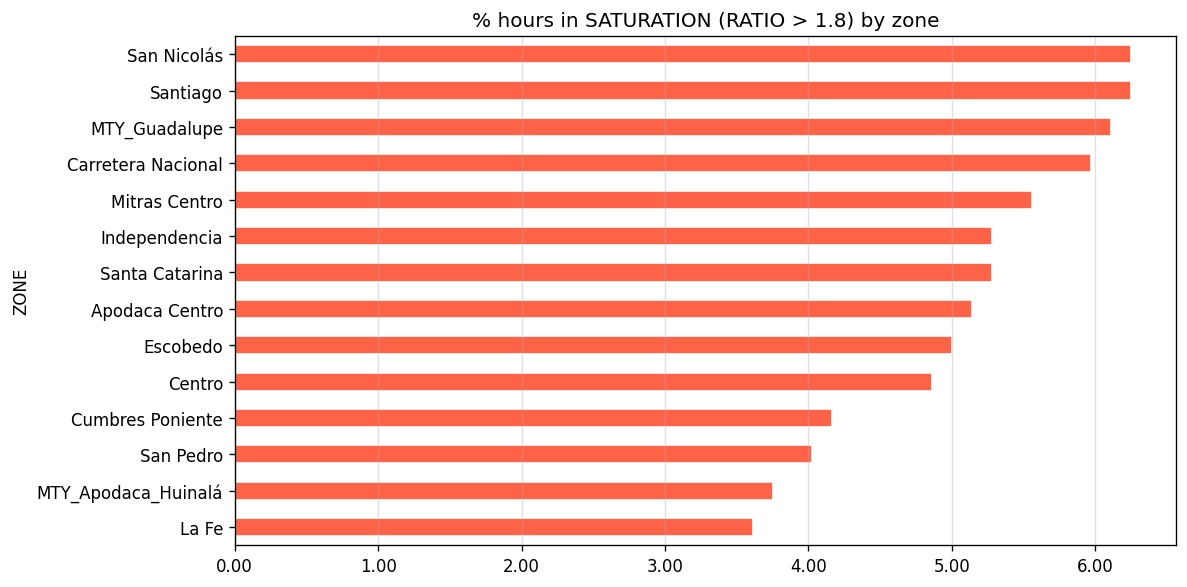

Figure saved → outputs\figures\p1_zone_hour_saturation_bubble.png


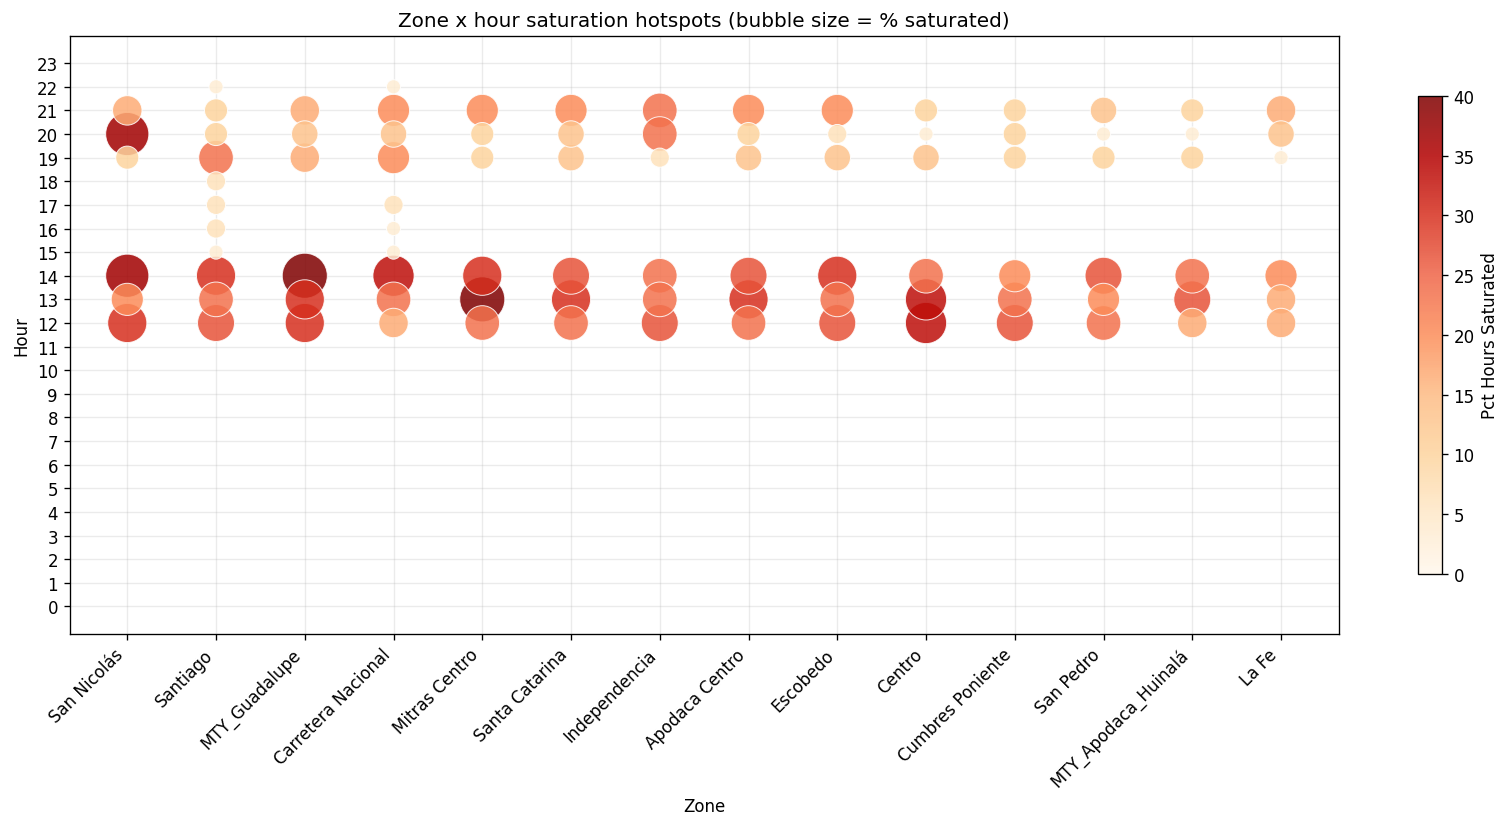

In [3]:
# Saturation event quantification
total_valid = len(raw_valid)
saturation_events = raw_valid[raw_valid["IS_SATURATED"]]
pct_saturation = len(saturation_events) / total_valid * 100

print(f"Total observations with riders > 0:  {total_valid:,}")
print(f"Saturation events (RATIO > {RATIO_SATURATION}):  {len(saturation_events):,}  ({pct_saturation:.1f}%)")

zone_sat = (
    raw_valid.groupby("ZONE")
    .agg(
        avg_ratio=("RATIO", "mean"),
        pct_hours_saturated=("IS_SATURATED", "mean"),
        n_observations=("IS_SATURATED", "size"),
    )
    .reset_index()
)
zone_sat["pct_hours_saturated"] *= 100
zone_sat = zone_sat.sort_values(["pct_hours_saturated", "avg_ratio"], ascending=[False, False])

zone_hour_sat = (
    raw_valid.groupby(["ZONE", "HOUR"])
    .agg(
        avg_ratio=("RATIO", "mean"),
        pct_hours_saturated=("IS_SATURATED", "mean"),
        n_days=("IS_SATURATED", "size"),
    )
    .reset_index()
)
zone_hour_sat["pct_hours_saturated"] *= 100
zone_hour_sat = zone_hour_sat.sort_values(["pct_hours_saturated", "avg_ratio"], ascending=[False, False])

print("\nZone ranking - % of hours in saturation:")
print(zone_sat.round({"avg_ratio": 3, "pct_hours_saturated": 2}).to_string(index=False))

print("\nTop zone x hour saturation hotspots:")
print(zone_hour_sat.head(12).round({"avg_ratio": 3, "pct_hours_saturated": 2}).to_string(index=False))

save_csv(zone_sat, TABLES_DIR / "p1_zone_saturation_frequency.csv")
save_csv(zone_hour_sat, TABLES_DIR / "p1_zone_hour_saturation_frequency.csv")

fig = plot_ranked_bar(
    zone_sat.set_index("ZONE")["pct_hours_saturated"],
    title="% hours in SATURATION (RATIO > 1.8) by zone",
    color="tomato",
)
save_fig(fig, "p1_zone_saturation_pct")
plt.show()

fig = plot_bubble_grid(
    zone_hour_sat,
    x="ZONE",
    y="HOUR",
    size="pct_hours_saturated",
    color="pct_hours_saturated",
    x_order=zone_sat["ZONE"].tolist(),
    y_order=list(range(24)),
    title="Zone x hour saturation hotspots (bubble size = % saturated)",
    figsize=(14, 7),
    size_scale=18,
    min_size=12,
    cmap="OrRd",
)
save_fig(fig, "p1_zone_hour_saturation_bubble")
plt.show()

In [4]:
# Identify the peak saturation hours overall
hour_sat = (
    raw_valid.groupby("HOUR")
    .agg(
        avg_ratio=("RATIO", "mean"),
        pct_hours_saturated=("IS_SATURATED", "mean"),
        n_observations=("IS_SATURATED", "size"),
    )
    .reset_index()
)
hour_sat["pct_hours_saturated"] *= 100
hour_sat = hour_sat.sort_values(["pct_hours_saturated", "avg_ratio"], ascending=[False, False])
print("Hours ranked by saturation frequency:")
print(hour_sat.head(10).round({"avg_ratio": 3, "pct_hours_saturated": 2}).to_string(index=False))
save_csv(hour_sat, TABLES_DIR / "p1_hour_saturation_frequency.csv")

Hours ranked by saturation frequency:
 HOUR  avg_ratio  pct_hours_saturated  n_observations
   14      1.596                27.86             420
   13      1.525                25.95             420
   12      1.521                24.52             420
   21      1.396                16.19             420
   19      1.366                12.38             420
   20      1.362                12.14             420
   17      0.838                 0.95             420
   16      0.824                 0.71             420
   22      0.993                 0.48             420
   18      0.846                 0.48             420
Saved CSV    → outputs\tables\p1_hour_saturation_frequency.csv  (24 rows)


---
## P2 - External Variable Correlated with Ratio Deterioration

**Question:** Which external variable in the dataset correlates with deterioration of the operational ratio?  
**Hypothesis:** Precipitation (`PRECIPITATION_MM`) raises customer demand faster than rider supply can respond, so `RATIO = ORDERS / CONNECTED_RT` deteriorates during rain events.

In [5]:
df_p2 = raw_valid.dropna(subset=["PRECIPITATION_MM", "RATIO"]).copy()
rain_order = ["no_rain", "light", "moderate", "heavy"]

# Overall Spearman correlation
r_overall, p_overall = spearmanr(df_p2["PRECIPITATION_MM"], df_p2["RATIO"])
print(f"Overall Spearman: PRECIPITATION_MM vs RATIO  r={r_overall:.4f}, p={p_overall:.2e}")

# Correlation of PRECIPITATION_MM with each mechanism variable
for target in ["CONNECTED_RT", "ORDERS", "EARNINGS"]:
    r, p = spearmanr(df_p2["PRECIPITATION_MM"], df_p2[target])
    print(f"PRECIPITATION_MM vs {target:15s}  r={r:.4f}, p={p:.2e}")

# Binned precipitation -> avg RATIO and mechanism table
rain_ratio = (
    df_p2.groupby("RAIN_BUCKET")
    .agg(
        avg_ratio=("RATIO", "mean"),
        median_ratio=("RATIO", "median"),
        avg_connected_rt=("CONNECTED_RT", "mean"),
        avg_orders=("ORDERS", "mean"),
        pct_hours_saturated=("IS_SATURATED", "mean"),
        n=("RATIO", "count"),
    )
    .reindex(rain_order)
)
rain_ratio["pct_hours_saturated"] *= 100
baseline_orders = rain_ratio.loc["no_rain", "avg_orders"]
baseline_rt = rain_ratio.loc["no_rain", "avg_connected_rt"]
rain_ratio["delta_orders_vs_no_rain"] = rain_ratio["avg_orders"] - baseline_orders
rain_ratio["delta_connected_rt_vs_no_rain"] = rain_ratio["avg_connected_rt"] - baseline_rt

print("\nAvg RATIO by rain bucket:")
print(rain_ratio.round(3).to_string())
save_csv(rain_ratio.reset_index(), TABLES_DIR / "p2_rain_bucket_ratio.csv")

# Same-hour comparison to reduce time-of-day confounding
hour_rain_ratio = (
    df_p2.groupby(["HOUR", "RAIN_BUCKET"])["RATIO"]
    .mean()
    .unstack("RAIN_BUCKET")
)
hour_rain_ratio = hour_rain_ratio[[c for c in rain_order if c in hour_rain_ratio.columns]]
hour_control_lift = hour_rain_ratio.subtract(hour_rain_ratio["no_rain"], axis=0)

# Print only the lunch and dinner peak windows highlighted in P1.
selected_hours = [h for h in [12, 13, 14, 19, 20, 21] if h in hour_control_lift.index]
selected_buckets = [c for c in ["light", "moderate", "heavy"] if c in hour_control_lift.columns]
print("\nWithin-hour RATIO lift vs no_rain (selected peak hours):")
print(hour_control_lift.loc[selected_hours, selected_buckets].round(3).to_string())
save_csv(hour_control_lift.reset_index(), TABLES_DIR / "p2_hour_control_ratio_lift.csv")

Overall Spearman: PRECIPITATION_MM vs RATIO  r=0.2307, p=6.48e-122
PRECIPITATION_MM vs CONNECTED_RT     r=0.1140, p=1.68e-30
PRECIPITATION_MM vs ORDERS           r=0.1934, p=1.45e-85
PRECIPITATION_MM vs EARNINGS         r=0.1584, p=1.31e-57

Avg RATIO by rain bucket:
             avg_ratio  median_ratio  avg_connected_rt  avg_orders  pct_hours_saturated     n  delta_orders_vs_no_rain  delta_connected_rt_vs_no_rain
RAIN_BUCKET                                                                                                                                          
no_rain          0.775         0.778             8.940       8.867                3.677  9464                    0.000                          0.000
light            1.060         0.875             8.937      11.424               17.227   238                    2.557                         -0.003
moderate         1.700         1.500            13.097      21.117               31.169   154                   12.249              

Figure saved → outputs\figures\p2_avg_ratio_by_rain_bucket.png


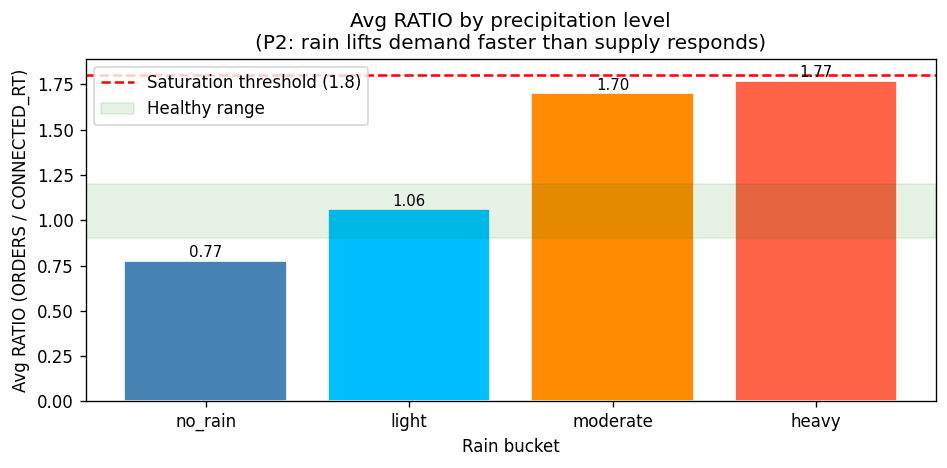

Figure saved → outputs\figures\p2_ratio_by_hour_rain_controlled.png


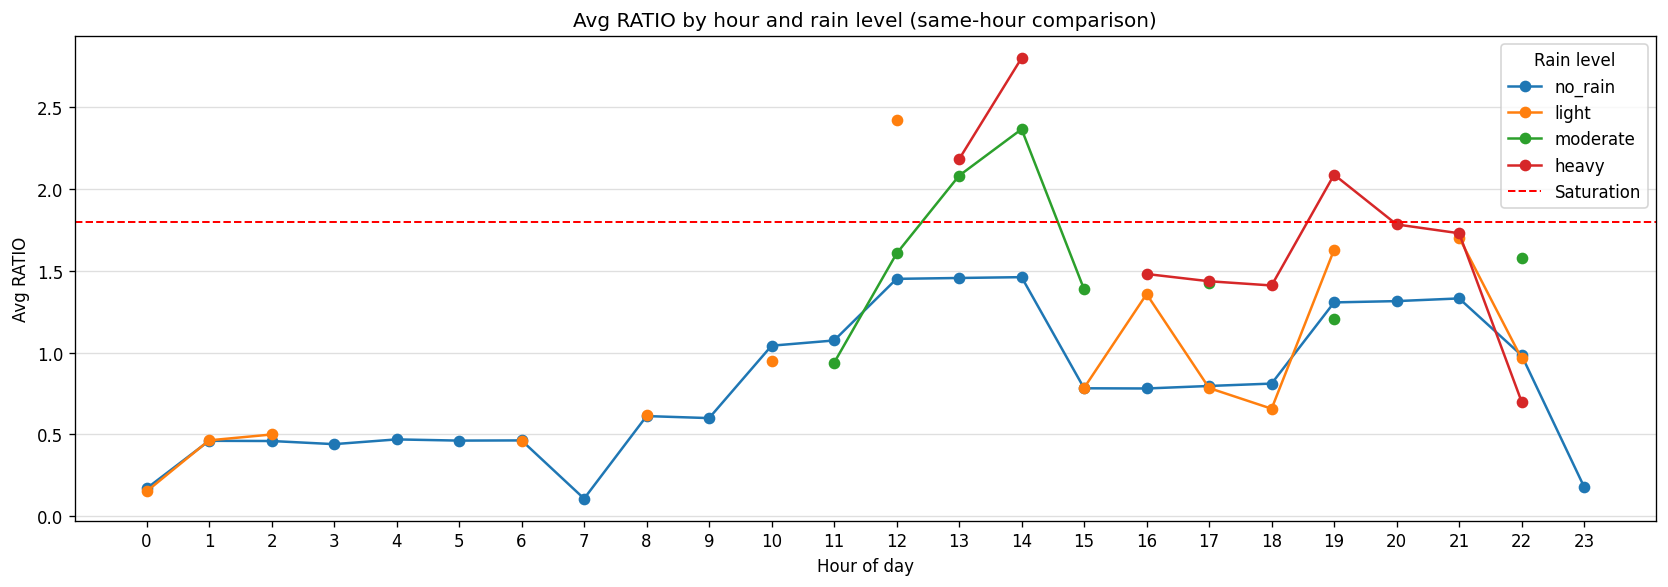

In [6]:
# # Visual comparison across all 24 hours for rainy buckets only.
# hour_rain_plot = hour_rain_ratio[[c for c in ["light", "moderate", "heavy"] if c in hour_rain_ratio.columns]].copy()
# fig, ax = plt.subplots(figsize=(14, 6))
# hour_rain_plot.plot(
#     kind="bar",
#     ax=ax,
#     width=0.8,
#     color=["goldenrod", "darkorange", "firebrick"][: len(hour_rain_plot.columns)],
#     edgecolor="white",
# )
# ax.axhline(RATIO_SATURATION, color="red", linestyle="--", linewidth=1.2, label=f"Saturation ({RATIO_SATURATION})")
# ax.set_title("Within-hour average RATIO by rain bucket")
# ax.set_xlabel("Hour of day")
# ax.set_ylabel("Average RATIO")
# ax.grid(axis="y", alpha=0.35)
# ax.legend(title="RAIN_BUCKET")
# fig.tight_layout()
# save_fig(fig, "p2_hourly_ratio_by_rain_bucket")
# plt.show()

# Visualize: average RATIO by rain bucket
plot_data = rain_ratio.reindex([x for x in rain_order if x in rain_ratio.index])

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    plot_data.index,
    plot_data["avg_ratio"],
    color=["steelblue", "deepskyblue", "darkorange", "tomato"],
    edgecolor="white",
)
ax.axhline(RATIO_SATURATION, color="red", linestyle="--", linewidth=1.5, label=f"Saturation threshold ({RATIO_SATURATION})")
ax.axhspan(RATIO_HEALTHY_LOW, RATIO_HEALTHY_HIGH, alpha=0.1, color="green", label="Healthy range")
ax.set_title("Avg RATIO by precipitation level\n(P2: rain lifts demand faster than supply responds)")
ax.set_ylabel("Avg RATIO (ORDERS / CONNECTED_RT)")
ax.set_xlabel("Rain bucket")
ax.legend()
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.2f}",
        ha="center",
        fontsize=9,
    )
plt.tight_layout()
save_fig(fig, "p2_avg_ratio_by_rain_bucket")
plt.show()

# Control for hour-of-day: does the rain effect hold within the same hour?
fig, ax = plt.subplots(figsize=(14, 5))
for bucket in hour_rain_ratio.columns:
    ax.plot(hour_rain_ratio.index, hour_rain_ratio[bucket], marker="o", label=bucket)
ax.axhline(RATIO_SATURATION, color="red", linestyle="--", linewidth=1.2, label="Saturation")
ax.set_title("Avg RATIO by hour and rain level (same-hour comparison)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Avg RATIO")
ax.set_xticks(range(0, 24))
ax.legend(title="Rain level")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
save_fig(fig, "p2_ratio_by_hour_rain_controlled")
plt.show()

---
## P3 - Zone Vulnerability to Precipitation

**Question:** Do all zones respond equally to precipitation? Which are the most vulnerable?  
**Method:** Combine per-zone Spearman correlation with an operational lift metric: how much `RATIO` increases in moderate/heavy rain relative to no-rain periods, and whether order growth outpaces rider growth.

In [7]:
zone_sensitivity = []
for zone, grp in df_p2.groupby("ZONE"):
    if len(grp) < 10:
        continue

    r_ratio, p_ratio = spearmanr(grp["PRECIPITATION_MM"], grp["RATIO"])
    no_rain = grp[grp["RAIN_BUCKET"] == "no_rain"]
    mod_plus = grp[grp["PRECIPITATION_MM"] >= 2.0] # Moderate and heavy buckets
    if no_rain.empty or mod_plus.empty:
        continue

    avg_ratio_no_rain = no_rain["RATIO"].mean()
    avg_ratio_mod_plus = mod_plus["RATIO"].mean()
    orders_lift = mod_plus["ORDERS"].mean() - no_rain["ORDERS"].mean()
    connected_rt_lift = mod_plus["CONNECTED_RT"].mean() - no_rain["CONNECTED_RT"].mean()

    zone_sensitivity.append({
        "ZONE": zone,
        "spearman_precip_ratio": round(r_ratio, 4),
        "p_value": round(p_ratio, 4),
        "avg_ratio_no_rain": round(avg_ratio_no_rain, 3),
        "avg_ratio_moderate_plus": round(avg_ratio_mod_plus, 3),
        "ratio_lift": round(avg_ratio_mod_plus - avg_ratio_no_rain, 3),
        "orders_lift": round(orders_lift, 3),
        "connected_rt_lift": round(connected_rt_lift, 3),
        "response_gap_orders_minus_rt": round(orders_lift - connected_rt_lift, 3),
        "n_observations": len(grp),
        "n_moderate_plus": int((grp["PRECIPITATION_MM"] >= 2.0).sum()),
    })

sensitivity_df = pd.DataFrame(zone_sensitivity).sort_values(
    ["ratio_lift", "spearman_precip_ratio"],
    ascending=[False, False],
)
print("Zone vulnerability to rain (sorted by RATIO lift in moderate/heavy rain):")
print(sensitivity_df.to_string(index=False))
save_csv(sensitivity_df, TABLES_DIR / "p3_zone_precipitation_sensitivity.csv")

Zone vulnerability to rain (sorted by RATIO lift in moderate/heavy rain):
               ZONE  spearman_precip_ratio  p_value  avg_ratio_no_rain  avg_ratio_moderate_plus  ratio_lift  orders_lift  connected_rt_lift  response_gap_orders_minus_rt  n_observations  n_moderate_plus
           Santiago                 0.2730      0.0              0.618                    2.439       1.821        6.691              0.924                         5.767             720               27
 Carretera Nacional                 0.2719      0.0              0.642                    2.126       1.484        9.044              1.980                         7.063             720               27
MTY_Apodaca_Huinalá                 0.2235      0.0              0.614                    1.675       1.061        6.609              2.485                         4.124             720               27
     Santa Catarina                 0.2420      0.0              0.877                    1.868       0.991       

Figure saved → outputs\figures\p3_zone_ratio_lift_rain.png


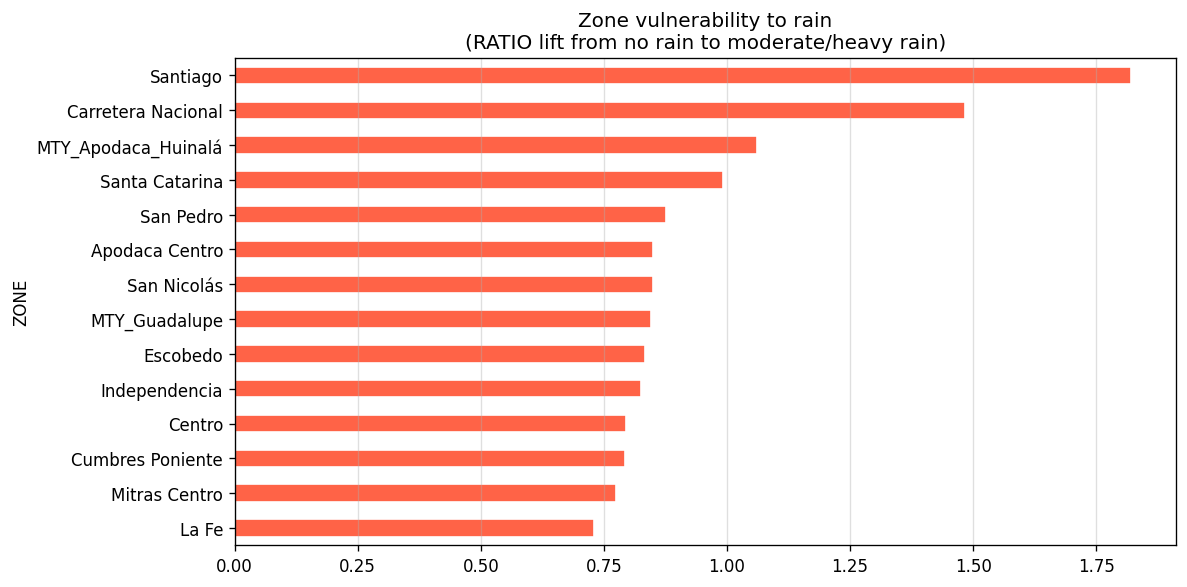

Figure saved → outputs\figures\p3_zone_response_gap_rain.png


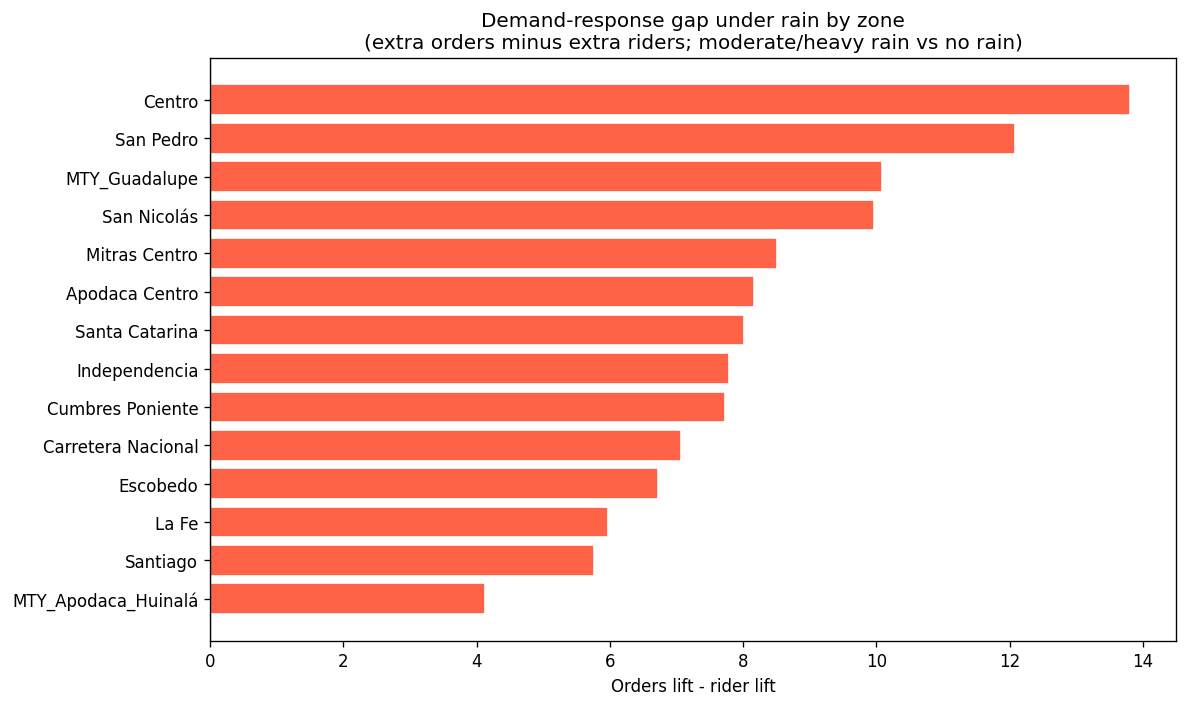

In [8]:
fig = plot_ranked_bar(
    sensitivity_df.set_index("ZONE")["ratio_lift"],
    title="Zone vulnerability to rain\n(RATIO lift from no rain to moderate/heavy rain)",
    color="tomato",
)
save_fig(fig, "p3_zone_ratio_lift_rain")
plt.show()

response_plot = sensitivity_df.sort_values("response_gap_orders_minus_rt", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    response_plot["ZONE"],
    response_plot["response_gap_orders_minus_rt"],
    color=["tomato" if v > 0 else "steelblue" for v in response_plot["response_gap_orders_minus_rt"]],
    edgecolor="white",
)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_title("Demand-response gap under rain by zone\n(extra orders minus extra riders; moderate/heavy rain vs no rain)")
ax.set_xlabel("Orders lift - rider lift")
plt.tight_layout()
save_fig(fig, "p3_zone_response_gap_rain")
plt.show()

---
## P4 - Earnings Calibration Across the Month

**Question:** Is the earnings level well-calibrated across the 30 days?  
Are there periods with excessive spend (high earnings + healthy ratio) or under-investment (low earnings + critical ratio)?

**Approach:** Check calibration at two levels:
1. Daily averages for budget-timing signals.
2. Intraday zone x hour flags to catch pockets of under-investment hidden by daily averages.

In [9]:
# Daily aggregation
daily = raw_valid.groupby("DATE").agg(
    avg_earnings=("EARNINGS", "mean"),
    median_earnings=("EARNINGS", "median"),
    avg_ratio=("RATIO", "mean"),
    pct_saturated=("IS_SATURATED", "mean"),
    total_orders=("ORDERS", "sum"),
    avg_precipitation=("PRECIPITATION_MM", "mean"),
).reset_index()
daily["pct_saturated"] *= 100

# Percentile thresholds for daily labels
earnings_high = daily["avg_earnings"].quantile(0.75)
earnings_low = daily["avg_earnings"].quantile(0.25)

daily["earnings_label"] = np.where(
    daily["avg_earnings"] >= earnings_high,
    "high",
    np.where(daily["avg_earnings"] <= earnings_low, "low", "normal"),
)
daily["ratio_label"] = np.where(
    daily["avg_ratio"] > RATIO_SATURATION,
    "saturated",
    np.where(daily["avg_ratio"] > RATIO_HEALTHY_HIGH, "strained", "healthy"),
)

overspend = daily[(daily["earnings_label"] == "high") & (daily["ratio_label"] == "healthy")]
under_invest = daily[(daily["earnings_label"] == "low") & (daily["ratio_label"].isin(["strained", "saturated"]))]

print("Daily-average thresholds used:")
print(f"  high earnings: avg_earnings >= {earnings_high:.3f} (75th percentile)")
print(f"  low earnings:  avg_earnings <= {earnings_low:.3f} (25th percentile)")
print(f"  healthy ratio: avg_ratio <= {RATIO_HEALTHY_HIGH:.1f}")
print(f"  strained ratio: {RATIO_HEALTHY_HIGH:.1f} < avg_ratio <= {RATIO_SATURATION:.1f}")
print(f"  saturated ratio: avg_ratio > {RATIO_SATURATION:.1f}")

print(f"\nDaily-average overspend days (high earnings, healthy ratio): {len(overspend)}")
if not overspend.empty:
    overspend_print = overspend[["DATE", "avg_earnings", "avg_ratio", "pct_saturated"]].copy()
    overspend_print[["avg_earnings", "avg_ratio", "pct_saturated"]] = overspend_print[["avg_earnings", "avg_ratio", "pct_saturated"]].round(3)
    print(overspend_print.to_string(index=False))

print(f"\nDaily-average under-investment days (low earnings, strained/saturated ratio): {len(under_invest)}")
if not under_invest.empty:
    under_print = under_invest[["DATE", "avg_earnings", "avg_ratio", "pct_saturated"]].copy()
    under_print[["avg_earnings", "avg_ratio", "pct_saturated"]] = under_print[["avg_earnings", "avg_ratio", "pct_saturated"]].round(3)
    print(under_print.to_string(index=False))
else:
    print("None at daily-average level.")

# Intraday calibration check: zone x hour flags
hourly_earnings_high = raw_valid["EARNINGS"].quantile(0.75)
hourly_earnings_low = raw_valid["EARNINGS"].quantile(0.25)

intraday_flags = raw_valid.assign(
    overspend_flag=(raw_valid["EARNINGS"] >= hourly_earnings_high) & (raw_valid["RATIO"] < RATIO_HEALTHY_LOW),
    under_invest_flag=(raw_valid["EARNINGS"] <= hourly_earnings_low) & (raw_valid["RATIO"] > RATIO_SATURATION),
)

daily_intraday = intraday_flags.groupby("DATE").agg(
    overspend_zone_hours=("overspend_flag", "sum"),
    under_invest_zone_hours=("under_invest_flag", "sum"),
    n_zone_hours=("RATIO", "size"),
).reset_index()
daily_intraday["pct_zone_hours_overspend"] = daily_intraday["overspend_zone_hours"] / daily_intraday["n_zone_hours"] * 100
daily_intraday["pct_zone_hours_under_invest"] = daily_intraday["under_invest_zone_hours"] / daily_intraday["n_zone_hours"] * 100

overspend_intraday_print = (
    daily_intraday
    .sort_values("overspend_zone_hours", ascending=False)
    .head(10)
    [["DATE", "overspend_zone_hours", "pct_zone_hours_overspend"]]
    .copy()
)
overspend_intraday_print["pct_zone_hours_overspend"] = overspend_intraday_print["pct_zone_hours_overspend"].round(2)
print("\nIntraday thresholds used:")
print(f"  high hourly earnings: EARNINGS >= {hourly_earnings_high:.3f} (75th percentile)")
print(f"  low hourly earnings:  EARNINGS <= {hourly_earnings_low:.3f} (25th percentile)")
print(f"  overspend flag ratio cutoff: RATIO < {RATIO_HEALTHY_LOW:.1f}")
print(f"  under-investment flag ratio cutoff: RATIO > {RATIO_SATURATION:.1f}")

print("\nDays with the most intraday overspend flags (high earnings + RATIO < 0.9):")
if not overspend_intraday_print.empty:
    print(overspend_intraday_print.to_string(index=False))
else:
    print("None at intraday level.")

under_intraday_print = (
    daily_intraday[daily_intraday["under_invest_zone_hours"] > 0]
    .sort_values("under_invest_zone_hours", ascending=False)
    .head(10)
    [["DATE", "under_invest_zone_hours", "pct_zone_hours_under_invest"]]
    .copy()
)
under_intraday_print["pct_zone_hours_under_invest"] = under_intraday_print["pct_zone_hours_under_invest"].round(2)
print("\nDays with the most intraday under-investment flags (low earnings + RATIO > 1.8):")
if not under_intraday_print.empty:
    print(under_intraday_print.to_string(index=False))
else:
    print("None at intraday level.")

daily = daily.merge(daily_intraday, on="DATE", how="left")
save_csv(daily, TABLES_DIR / "p4_daily_earnings_ratio.csv")
save_csv(daily_intraday, TABLES_DIR / "p4_intraday_inefficiency_days.csv")

Daily-average thresholds used:
  high earnings: avg_earnings >= 57.336 (75th percentile)
  low earnings:  avg_earnings <= 56.676 (25th percentile)
  healthy ratio: avg_ratio <= 1.2
  strained ratio: 1.2 < avg_ratio <= 1.8
  saturated ratio: avg_ratio > 1.8

Daily-average overspend days (high earnings, healthy ratio): 8
      DATE  avg_earnings  avg_ratio  pct_saturated
2024-03-03        60.749      0.747          3.571
2024-03-07        59.742      0.760          3.274
2024-03-11        57.378      0.794          4.464
2024-03-12        62.137      0.780          3.571
2024-03-14        60.445      0.746          5.060
2024-03-15        59.507      0.806          2.083
2024-03-20        60.051      0.794          2.679
2024-03-22        61.064      0.737          3.869

Daily-average under-investment days (low earnings, strained/saturated ratio): 0
None at daily-average level.

Intraday thresholds used:
  high hourly earnings: EARNINGS >= 58.700 (75th percentile)
  low hourly earnings:

Figure saved → outputs\figures\p4_daily_earnings_ratio_calibration.png


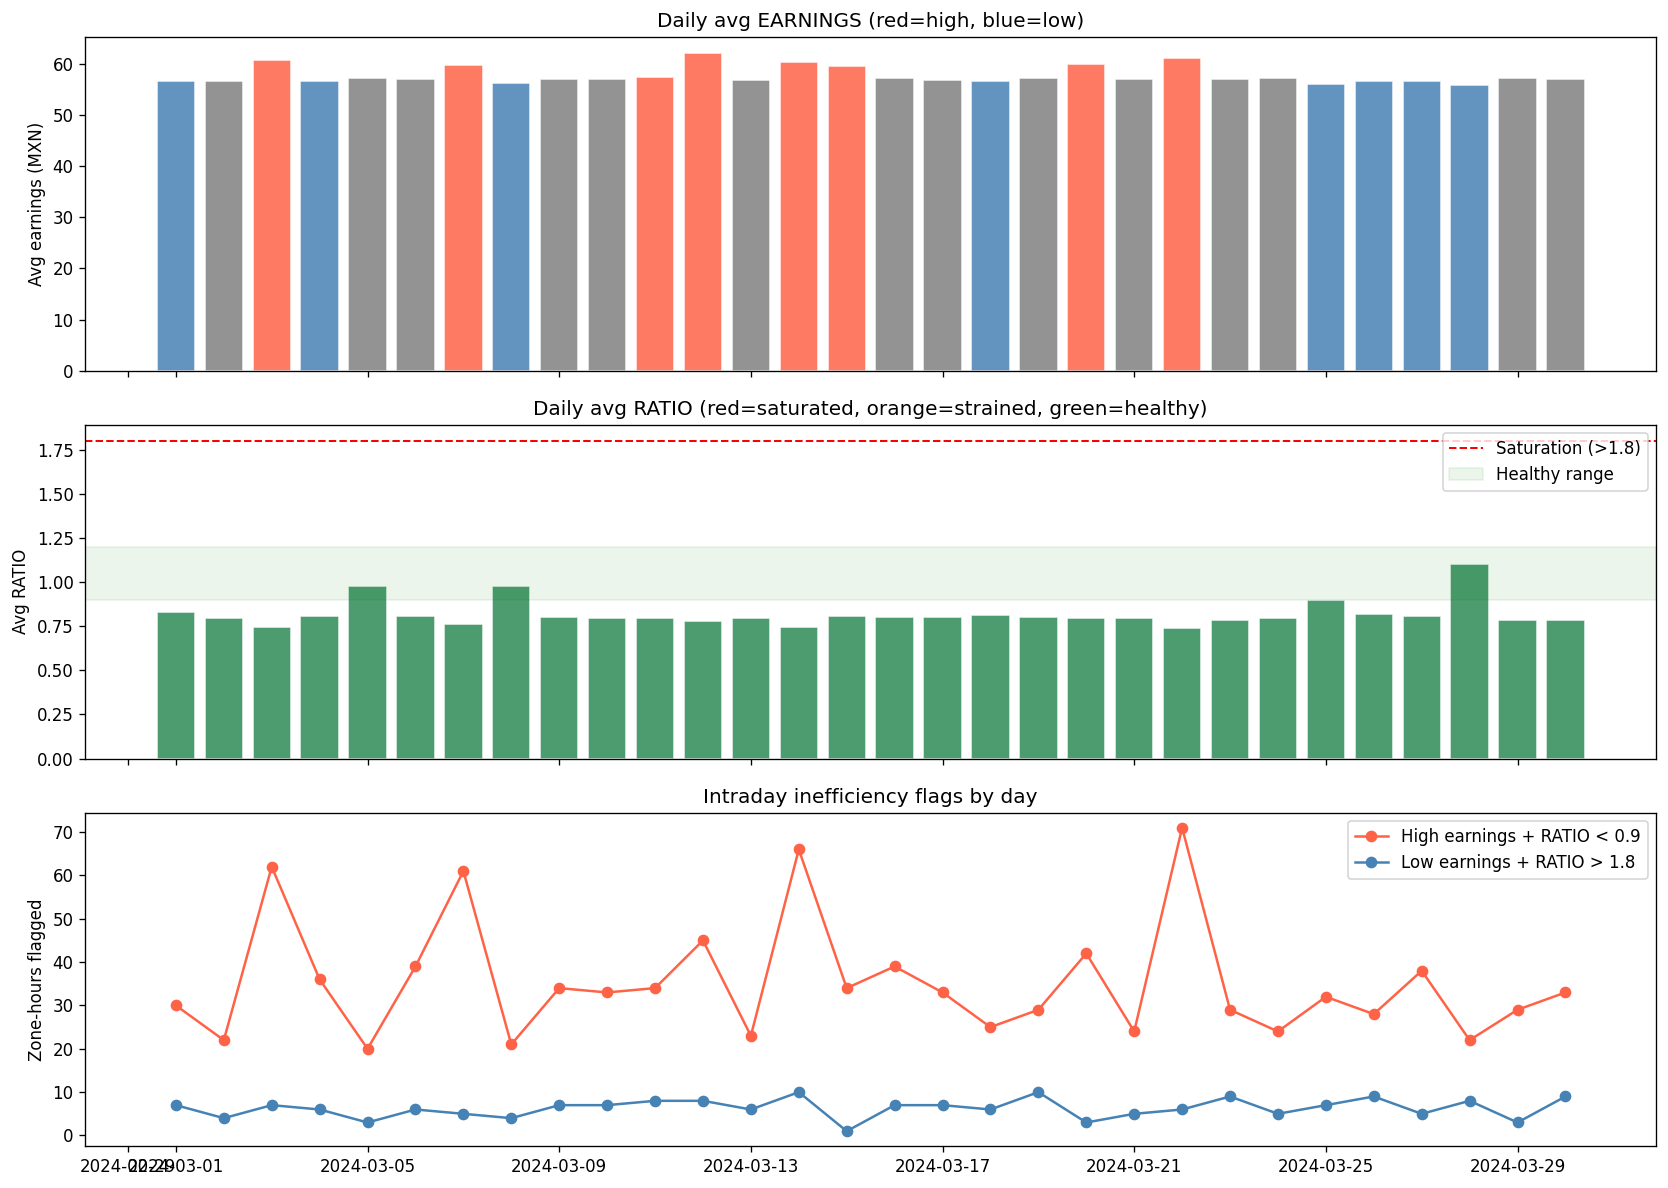

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
ax1, ax2, ax3 = axes

# Avg earnings per day
colors_e = [
    "tomato" if e == "high" else ("steelblue" if e == "low" else "gray")
    for e in daily["earnings_label"]
]
ax1.bar(daily["DATE"], daily["avg_earnings"], color=colors_e, edgecolor="white", alpha=0.85)
ax1.set_title("Daily avg EARNINGS (red=high, blue=low)")
ax1.set_ylabel("Avg earnings (MXN)")

# Avg ratio per day
colors_r = [
    "tomato" if r == "saturated" else ("darkorange" if r == "strained" else "seagreen")
    for r in daily["ratio_label"]
]
ax2.bar(daily["DATE"], daily["avg_ratio"], color=colors_r, edgecolor="white", alpha=0.85)
ax2.axhline(RATIO_SATURATION, color="red", linestyle="--", linewidth=1.2, label=f"Saturation (>{RATIO_SATURATION})")
ax2.axhspan(RATIO_HEALTHY_LOW, RATIO_HEALTHY_HIGH, color="green", alpha=0.08, label="Healthy range")
ax2.set_title("Daily avg RATIO (red=saturated, orange=strained, green=healthy)")
ax2.set_ylabel("Avg RATIO")
ax2.legend()

# Intraday inefficiency counts per day
ax3.plot(daily["DATE"], daily["overspend_zone_hours"], marker="o", color="tomato", label="High earnings + RATIO < 0.9")
ax3.plot(daily["DATE"], daily["under_invest_zone_hours"], marker="o", color="steelblue", label="Low earnings + RATIO > 1.8")
ax3.set_title("Intraday inefficiency flags by day")
ax3.set_ylabel("Zone-hours flagged")
ax3.legend()

plt.tight_layout()
save_fig(fig, "p4_daily_earnings_ratio_calibration")
plt.show()

### Intraday under-investment heatmap

These views show where intraday calibration problems happen inside the month, by plotting the number of flagged zones for each `(DATE, HOUR)` combination. Overspend and under-investment are shown in separate panels because the same day-hour can contain both across different zones.

Saved CSV    → outputs\tables\p4_overspend_heatmap.csv  (24 rows)
Saved CSV    → outputs\tables\p4_under_investment_heatmap.csv  (24 rows)
Figure saved → outputs\figures\p4_intraday_inefficiency_heatmaps.png


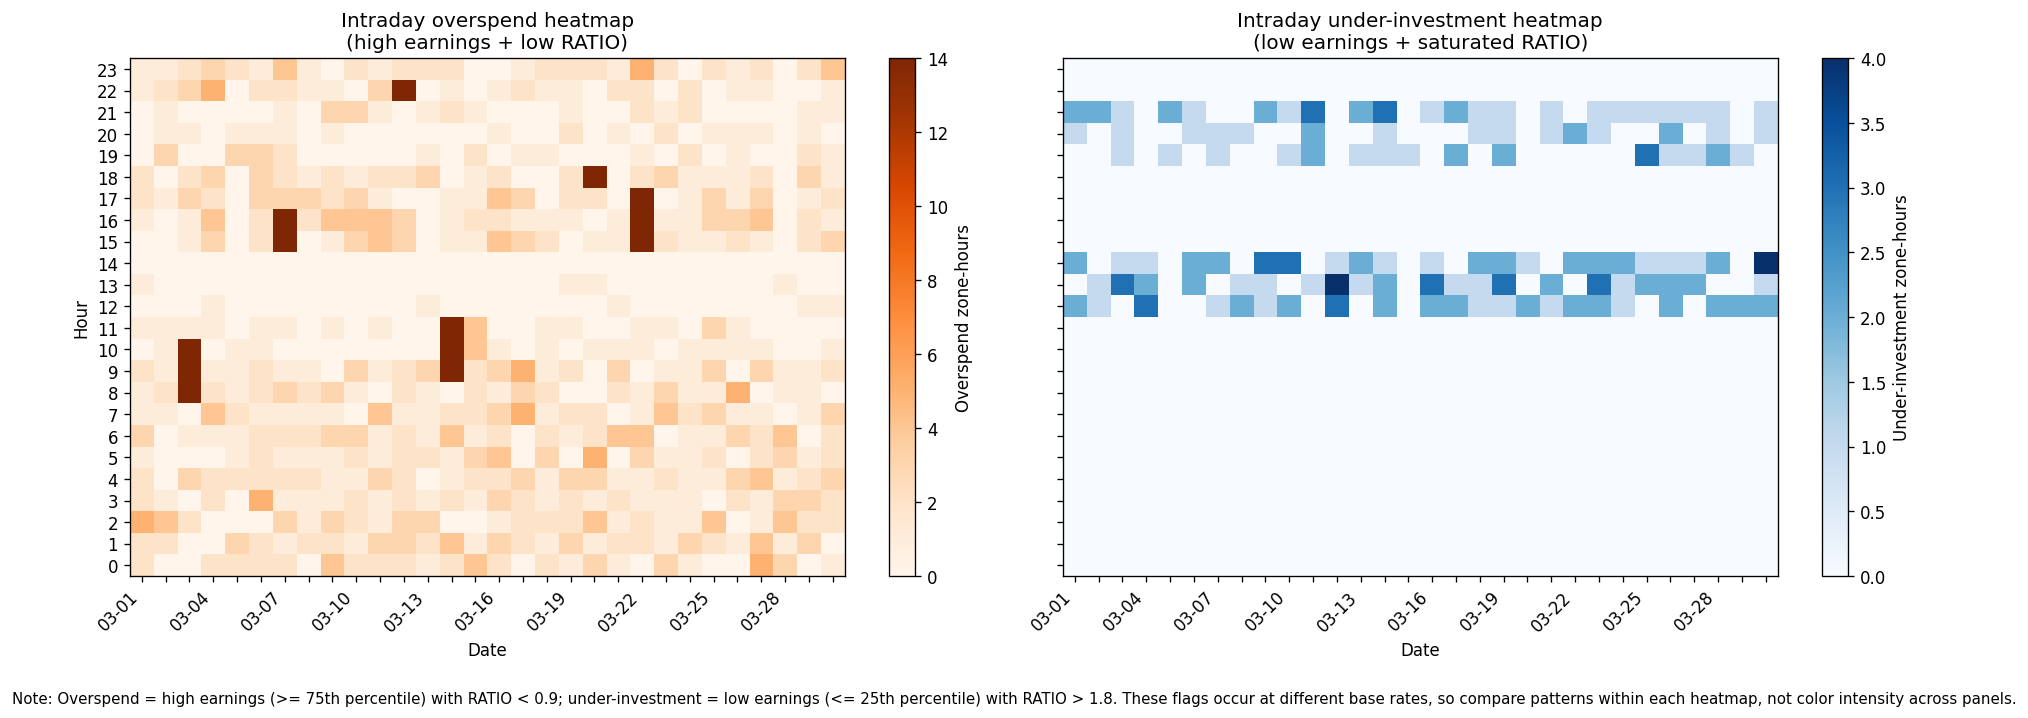

In [11]:
overspend_heat = (
    intraday_flags
    .groupby(["HOUR", "DATE"], as_index=False)["overspend_flag"]
    .sum()
)

overspend_pivot = (
    overspend_heat
    .pivot(index="HOUR", columns="DATE", values="overspend_flag")
    .fillna(0)
    .reindex(range(24), fill_value=0)
)
overspend_pivot = overspend_pivot.sort_index(axis=1)

under_heat = (
    intraday_flags
    .groupby(["HOUR", "DATE"], as_index=False)["under_invest_flag"]
    .sum()
)

under_pivot = (
    under_heat
    .pivot(index="HOUR", columns="DATE", values="under_invest_flag")
    .fillna(0)
    .reindex(range(24), fill_value=0)
)
under_pivot = under_pivot.sort_index(axis=1)

save_csv(overspend_pivot.reset_index(), TABLES_DIR / "p4_overspend_heatmap.csv")
save_csv(under_pivot.reset_index(), TABLES_DIR / "p4_under_investment_heatmap.csv")

date_labels = [
    pd.to_datetime(date).strftime("%m-%d") if i % 3 == 0 else ""
    for i, date in enumerate(under_pivot.columns)
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
ax1, ax2 = axes
im1 = ax1.imshow(overspend_pivot.values, aspect="auto", cmap="Oranges", origin="lower")
im2 = ax2.imshow(under_pivot.values, aspect="auto", cmap="Blues", origin="lower")

ax1.set_title("Intraday overspend heatmap\n(high earnings + low RATIO)")
ax2.set_title("Intraday under-investment heatmap\n(low earnings + saturated RATIO)")
ax1.set_ylabel("Hour")

for ax, pivot in [(ax1, overspend_pivot), (ax2, under_pivot)]:
    ax.set_xlabel("Date")
    ax.set_yticks(range(24))
    ax.set_yticklabels(range(24))
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(date_labels, rotation=45, ha="right")

cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label("Overspend zone-hours")
cbar2 = fig.colorbar(im2, ax=ax2)
cbar2.set_label("Under-investment zone-hours")

fig.text(
    0.5,
    0.01,
    "Note: Overspend = high earnings (>= 75th percentile) with RATIO < 0.9; under-investment = low earnings (<= 25th percentile) with RATIO > 1.8. These flags occur at different base rates, so compare patterns within each heatmap, not color intensity across panels.",
    ha="center",
    va="bottom",
    fontsize=9,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
save_fig(fig, "p4_intraday_inefficiency_heatmaps")
plt.show()

---
## P5 - Earnings-Saturation Relationship

**Question:** What is the relationship between earnings (incentives) and the saturation ratio?  
Is it a simple linear relationship, or does it depend on other conditions (e.g., rain)?  
**Hypothesis:** The earnings effect is conditional. In dry hours it is weak, but under moderate/heavy rain higher incentives should be associated with lower `RATIO` if incentives help rider supply catch up.

In [12]:
df_p5 = raw_valid.dropna(subset=["EARNINGS", "RATIO", "RAIN_BUCKET"]).copy()

# Overall Spearman: earnings vs ratio
r_e, p_e = spearmanr(df_p5["EARNINGS"], df_p5["RATIO"])
print(f"Overall Spearman: EARNINGS vs RATIO  r={r_e:.4f}, p={p_e:.2e}")

# Per rain-bucket correlation
print("\nEARNINGS -> RATIO relationship by rain condition:")
for bucket in rain_order:
    sub = df_p5[df_p5["RAIN_BUCKET"] == bucket]
    if len(sub) < 10:
        continue
    r, p = spearmanr(sub["EARNINGS"], sub["RATIO"])
    print(f"  {bucket:10s}: n={len(sub):5,}  Spearman r={r:.4f}  p={p:.3f}")

# Grouped means: earnings quartile x rain bucket -> avg RATIO, saturation %, sample size
df_p5["EARNINGS_Q"] = pd.qcut(df_p5["EARNINGS"], q=4, labels=["Q1_low", "Q2", "Q3", "Q4_high"])
interaction = (
    df_p5.groupby(["EARNINGS_Q", "RAIN_BUCKET"])
    .agg(
        avg_ratio=("RATIO", "mean"),
        pct_hours_saturated=("IS_SATURATED", "mean"),
        n=("RATIO", "size"),
    )
    .reset_index()
)
interaction["pct_hours_saturated"] *= 100
interaction = interaction[interaction["RAIN_BUCKET"].isin(rain_order)].copy()
interaction["EARNINGS_Q"] = pd.Categorical(interaction["EARNINGS_Q"], categories=["Q1_low", "Q2", "Q3", "Q4_high"], ordered=True)
interaction = interaction.sort_values(["EARNINGS_Q", "RAIN_BUCKET"])

print("\nEARNINGS x rain interaction (avg RATIO, saturation %, sample size):")
print(interaction.round(3).to_string(index=False))
save_csv(interaction, TABLES_DIR / "p5_earnings_rain_ratio_interaction.csv")

interaction_pivot = interaction.pivot(index="EARNINGS_Q", columns="RAIN_BUCKET", values="avg_ratio")
interaction_pivot = interaction_pivot.reindex(["Q1_low", "Q2", "Q3", "Q4_high"])

Overall Spearman: EARNINGS vs RATIO  r=0.0761, p=1.95e-14

EARNINGS -> RATIO relationship by rain condition:
  no_rain   : n=9,464  Spearman r=0.0494  p=0.000
  light     : n=  238  Spearman r=-0.1182  p=0.069
  moderate  : n=  154  Spearman r=-0.4172  p=0.000
  heavy     : n=  224  Spearman r=-0.6979  p=0.000

EARNINGS x rain interaction (avg RATIO, saturation %, sample size):
EARNINGS_Q RAIN_BUCKET  avg_ratio  pct_hours_saturated    n
    Q1_low       heavy      3.291               83.333    6
    Q1_low       light      1.701               40.000   10
    Q1_low    moderate      2.115               60.000    5
    Q1_low     no_rain      0.816                6.832 2576
        Q2       heavy      2.352               62.500   48
        Q2       light      1.083               22.500   80
        Q2    moderate      1.906               41.176   34
        Q2     no_rain      0.758                5.409 2348
        Q3       heavy      2.084               59.184   49
        Q3       li

Figure saved → outputs\figures\p5_earnings_rain_saturation_interaction.png


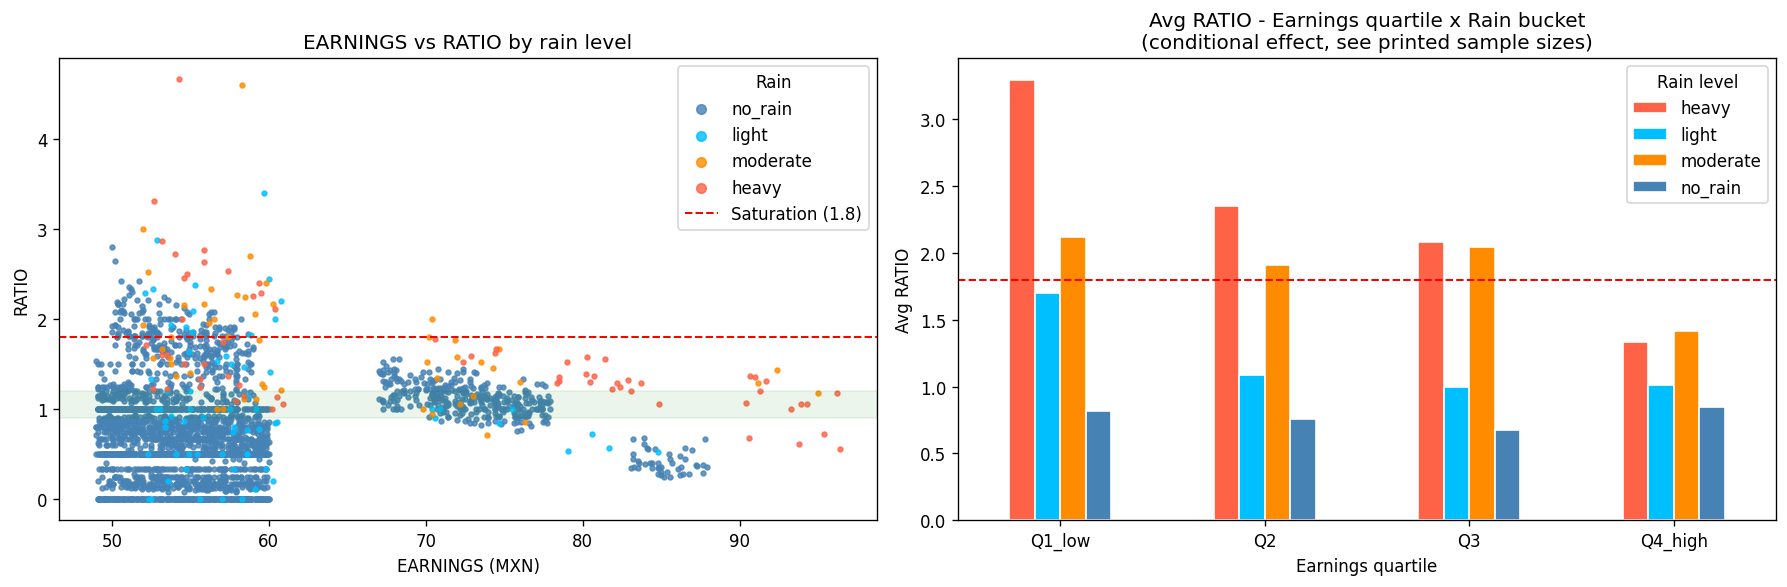

In [13]:
rain_colors = {"no_rain": "steelblue", "light": "deepskyblue", "moderate": "darkorange", "heavy": "tomato"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: scatter EARNINGS vs RATIO, colored by rain bucket
sample = df_p5.sample(min(3000, len(df_p5)), random_state=42)
for bucket in rain_order:
    sub = sample[sample["RAIN_BUCKET"] == bucket]
    axes[0].scatter(
        sub["EARNINGS"],
        sub["RATIO"],
        alpha=0.8,
        s=8,
        color=rain_colors.get(bucket, "gray"),
        label=bucket,
    )
axes[0].axhline(RATIO_SATURATION, color="red", linestyle="--", linewidth=1.2, label=f"Saturation ({RATIO_SATURATION})")
axes[0].axhspan(RATIO_HEALTHY_LOW, RATIO_HEALTHY_HIGH, alpha=0.08, color="green")
axes[0].set_title("EARNINGS vs RATIO by rain level")
axes[0].set_xlabel("EARNINGS (MXN)")
axes[0].set_ylabel("RATIO")
axes[0].legend(title="Rain", markerscale=2)

# Right: grouped bar - avg RATIO by earnings quartile x rain bucket
if not interaction_pivot.empty:
    interaction_pivot.plot(
        kind="bar",
        ax=axes[1],
        color=[rain_colors.get(c, "gray") for c in interaction_pivot.columns],
        edgecolor="white",
    )
    axes[1].axhline(RATIO_SATURATION, color="red", linestyle="--", linewidth=1.2)
    axes[1].set_title("Avg RATIO - Earnings quartile x Rain bucket\n(conditional effect, see printed sample sizes)")
    axes[1].set_xlabel("Earnings quartile")
    axes[1].set_ylabel("Avg RATIO")
    axes[1].legend(title="Rain level")
    axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
save_fig(fig, "p5_earnings_rain_saturation_interaction")
plt.show()

---
## Findings - Top 5 Business Insights

### Finding 1 - Saturation is concentrated in repeatable zone-hour hotspots (P1)
**Evidence:** Citywide, 513 of 10,080 valid observations are saturated (`5.1%`). The most exposed hours are `14:00` (`27.9%` saturated), `13:00` (`26.0%`), `12:00` (`24.5%`), and the dinner window `19:00-21:00` (`12.1%-16.2%`). At the zone level, `San Nicolas` and `Santiago` lead overall saturation frequency (`6.25%` each), but the sharper signal is the `zone x hour` table: `MTY_Guadalupe 14:00` and `Mitras Centro 13:00` are saturated on `40%` of days, with several other lunch peaks at `30%-36.7%`.  
**Interpretation:** The average city profile hides repeated local spikes. The operational problem is not "all day saturation" but predictable lunch and late-evening hotspots.  
**Action:** Staff and incentivize riders by zone-hour hotspot, not only by citywide peak windows.

---

### Finding 2 - Rain has a weak overall correlation with RATIO, but a strong segmented operational effect (P2)
**Evidence:** Overall, `PRECIPITATION_MM` has a positive but weak Spearman relationship with `RATIO` (`r=0.2307`, `p=6.48e-122`), so the signal is statistically real but not strong in the raw full-sample view. The bucketed analysis shows the operational effect more clearly: average `RATIO` rises from `0.775` in `no_rain` to `1.700` in `moderate` rain and `1.769` in `heavy` rain, while `% saturated` jumps from `3.68%` to `31.17%-33.93%`. Over the same buckets, average orders increase by about `+12` to `+15` vs no rain, while connected riders increase by only about `+4` to `+6`. The within-hour lift table shows that this deterioration still appears inside comparable lunch and dinner hours, especially around `13:00-14:00`.  
**Interpretation:** Rain should not be framed as a strong universal correlation across the whole dataset. It behaves more like a segmented stressor: the global correlation is diluted by many zero-rain observations, but once rain is present, especially at `moderate` and `heavy` levels, demand rises faster than supply can respond. Supply does react; it just does not keep pace with the demand spike.  
**Action:** Use weather-triggered incentives that scale by rain intensity and peak hour, with the strongest triggers on moderate/heavy rain lunch and dinner windows rather than a single citywide rain rule.

---

### Finding 3 - Rain affects all zones, but vulnerability depends on the metric you use (P3)
**Evidence:** Every zone has a positive precipitation-to-`RATIO` Spearman coefficient (about `0.21` to `0.27`), so the rain effect is widespread. The biggest `RATIO` lifts from `no_rain` to `moderate/heavy` rain are `Santiago` (`+1.821`), `Carretera Nacional` (`+1.484`), `MTY_Apodaca_Huinala` (`+1.061`), and `Santa Catarina` (`+0.991`). But the largest demand-response gaps (`orders_lift - connected_rt_lift`) are concentrated in higher-volume zones such as `Centro` (`+13.807`), `San Pedro` (`+12.075`), `MTY_Guadalupe` (`+10.089`), and `San Nicolas` (`+9.960`).  
**Interpretation:** All zones worsen under rain, but “most vulnerable” is not one single concept. Lower-baseline or peripheral zones show the sharpest relative `RATIO` deterioration, while denser zones absorb the largest absolute demand surges beyond rider response.  
**Action:** Use zone-specific weather tiers with two lenses: protect the highest `RATIO`-lift zones first, and separately monitor the high-volume zones where the absolute demand-response gap is largest.

---

### Finding 4 - Daily averages hide the timing problem; intraday inefficiency runs both ways (P4)
**Evidence:** At the daily-average level there are `8` overspend days and `0` under-investment days by the notebook's rule. The overspend dates are `2024-03-03`, `2024-03-07`, `2024-03-11`, `2024-03-12`, `2024-03-14`, `2024-03-15`, `2024-03-20`, and `2024-03-22`. But the intraday signal is much richer: high-earnings low-`RATIO` flags peak on `2024-03-22` (`71` zone-hours), `2024-03-14` (`66`), `2024-03-03` (`62`), and `2024-03-07` (`61`), while low-earnings saturated pockets recur on `2024-03-14` and `2024-03-19` (`10` each) and on `2024-03-23`, `2024-03-26`, and `2024-03-30` (`9` each). The new under-investment heatmap shows these low-earnings saturated flags concentrate almost entirely in peak hours `12:00-14:00` and `19:00-21:00`, rather than being spread through the day.  
**Interpretation:** The calibration issue is not mainly the total daily budget; it is when incentives are too high in low-pressure windows and too low in peak saturated windows. A day can look healthy on average while still hiding both overspend and under-investment pockets inside the day.  
**Action:** Move calibration logic from daily budgeting to hourly triggers tied to `RATIO`, weather, and peak windows, especially lunch and dinner.

---

### Finding 5 - The earnings effect is conditional, not simple (P5)
**Evidence:** Overall, `EARNINGS` has only a weak positive Spearman relationship with `RATIO` (`r=0.0761`), so there is no useful global rule in the full sample. Once we compare within the same rain bucket, the pattern changes: `light` rain is not statistically significant (`r=-0.1182`, `p=0.069`), while `moderate` and `heavy` rain show clear negative relationships (`r=-0.4172` and `r=-0.6979`). The interaction table points in the same direction with larger usable cells: in `heavy` rain, `Q4_high` averages `RATIO=1.336` and `9.9%` saturation versus `Q2-Q3` at `RATIO=2.084-2.352` and `59.2%-62.5%` saturation; in `moderate` rain, `Q4_high` is `1.414` and `13.0%` versus `Q2-Q3` at `1.906-2.042` and `41.2%-55.3%`. The rainy `Q1_low` cells are directionally consistent but very small and should be treated cautiously.  
**Interpretation:** Incentives are not a broad always-on lever. They look most valuable as a defensive tool when the marketplace is already under weather stress; in dry conditions, the earnings-`RATIO` relationship is weak and very low `RATIO` can also reflect oversupply, not only health.  
**Action:** Make incentive recommendations conditional on rain intensity and peak windows, and enforce minimum-sample safeguards before translating bucket-level uplift into policy.

---
## Risks and Caveats

| # | Risk / Caveat | Potential Impact | Mitigation |
|---|---|---|---|
| 1 | **Correlation is still not causation** | Same-hour comparisons reduce time-of-day confounding, but the notebook does not fit a formal causal or multivariate model | Add a regression / panel model with hour, date, zone, and rain controls before converting correlations into production policy |
| 2 | **CONNECTED_RT definition ambiguity** | "Connected riders" may mean riders online, riders with active orders, or riders inside a geo-fence - each changes how `RATIO` should be interpreted | Clarify the metric definition with Product/Ops and recompute KPIs if needed |
| 3 | **No rider-level data** | We cannot tell whether the supply response comes from more riders, longer rider sessions, or a smaller set of riders taking more orders | Request anonymized rider-level shift and acceptance data for Module 2 |
| 4 | **30-day window** | Seasonal effects and longer-run patterns are not captured | Re-run on a rolling 90-day or quarterly sample |
| 5 | **Join on zone names** | Any missed text normalization could silently drop rows in merged outputs | Keep validating join counts and request stable numeric zone IDs from source systems |
| 6 | **EARNINGS semantics need confirmation** | The business meaning of `EARNINGS` (per-order incentive vs hourly total payout) changes how calibration findings should be interpreted | Confirm the exact metric definition with Ops and rename the field in downstream reports |
| 7 | **Sparse rain interaction cells** | Aggregate rain buckets are usable, but some `EARNINGS_Q x RAIN_BUCKET` cells, especially rainy `Q1_low`, are tiny and can overstate extremes | Carry sample sizes into every policy rule and pool or shrink low-count cells toward broader benchmarks |
| 8 | **Lower `RATIO` is not always better** | In dry periods, very low `RATIO` can reflect oversupply / low utilization rather than a healthier marketplace | Evaluate incentive rules against both saturation reduction and utilization / cost guardrails |

---
## Executive Summary

### Data Scope
- **City:** Monterrey | **Period:** 30 days | **Grain:** Zone x Hour (10,080 rows across 14 zones x 24 hours x 30 days)
- **Metric of interest:** `RATIO = ORDERS / CONNECTED_RT` - the primary signal for supply-demand balance

### City-Level KPI Snapshot
- **City avg RATIO:** `0.818`
- **Healthy share (`0.9-1.2`):** `24.8%` of zone-hours
- **Saturation share (`>1.8`):** `5.1%` of zone-hours
- **Over-supply share (`<0.5`):** `22.4%` of zone-hours
- **Most exposed hours:** `12:00-14:00` and `19:00-21:00`

### What the analysis says
1. **Peak-hour saturation is real but localized.** The worst lunch hotspots are saturated on `30%-40%` of days even though full-zone averages stay below the saturation threshold.
2. **Rain is the main contextual stressor.** The overall rain-`RATIO` correlation is weak, but once rain is present, especially at `moderate` and `heavy` levels, `RATIO` nearly doubles because demand rises faster than supply.
3. **Zone vulnerability is uneven and metric-dependent.** `Santiago`, `Carretera Nacional`, `MTY_Apodaca_Huinala`, and `Santa Catarina` show the biggest relative `RATIO` lifts, while `Centro`, `San Pedro`, `MTY_Guadalupe`, and `San Nicolas` absorb the largest absolute demand-response gaps.
4. **Calibration problems are mostly intraday and two-sided.** Daily averages show `8` overspend dates and no daily under-investment days, but hourly flags reveal broad overspend in low-pressure windows and recurring under-investment pockets concentrated around `12:00-14:00` and `19:00-21:00`.
5. **Earnings are a conditional lever.** The global earnings-`RATIO` link is weak, but in `moderate/heavy` rain the highest earnings quartile is associated with materially lower `RATIO` and much lower saturation.

### Recommended Next Steps
- **Module 2:** Forecast `RATIO` by zone-hour using `HOUR`, `DAY_OF_WEEK`, `PRECIPITATION_MM`, and zone-level weather sensitivity.
- **Module 2 decisioning:** Trigger incentives on hotspot `zone x hour` pairs, not only citywide dayparts.
- **Module 3 messaging:** Explain both the risk driver (rain / hotspot hour) and the recommended action (zone-specific incentive adjustment) in each alert.

---
*Analysis conducted using pandas, scipy, matplotlib, and seaborn. Updated outputs are saved to `outputs/tables/` and `outputs/figures/`.*